# Data Curation: ChEMBL Bioactivity Data for Estrogen Receptor Alpha

**Target:** Estrogen Receptor Alpha (ERα), ChEMBL Target ID: `CHEMBL206`

**Dataset:** 7,260 bioactivity records downloaded from the ChEMBL database.

**Goal:** Transform raw bioactivity data into a **curated compound–activity dataset** through a series of defensible curation decisions.

---

## Workshop Overview

| Section | Topic |
|---------|-------|
| 1 | Loading and Initial Inspection |
| 2 | Understanding Bioactivity Semantics |
| 3 | Endpoint Selection |
| 4 | Molecule-Level Curation (with RDKit) |
| 5 | Duplicate Handling |
| 6 | Chemical Space Visualization |
| 7 | Value Consistency & Molecule Grids |
| 8 | Activity Classification |
| 9 | Data Splitting for ML |


## Setup

We use `pandas` for data manipulation, `matplotlib`/`seaborn` for visualization, and `rdkit` for chemical structure standardization.

In [1]:
!pip install rdkit

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Draw, rdFingerprintGenerator, AllChem, DataStructs
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit import RDLogger
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold, train_test_split, StratifiedKFold, StratifiedGroupKFold
from sklearn.base import clone
from sklearn.metrics import roc_auc_score, average_precision_score, balanced_accuracy_score, matthews_corrcoef
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print("Setup complete.")

Setup complete.


## 1. Loading and Initial Inspection

### 1.1 Loading the Data

In [2]:
!wget -q https://github.com/volkamerlab/ai_in_chemistry_workshop_2026/blob/main/notebooks/bioactivity_estrogenreceptor_chembl.zip

!unzip activities-chembl33-not-curated_v0.5.zip

'wget' is not recognized as an internal or external command,
operable program or batch file.
'unzip' is not recognized as an internal or external command,
operable program or batch file.


In [3]:
df = pd.read_csv('bioactivity_estrogenreceptor_chembl.csv', sep=';')

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(3)

Dataset shape: 7,260 rows × 30 columns


,Molecule ChEMBL ID,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,Standard Value,Standard Units,pChEMBL Value,Ligand Efficiency BEI,Ligand Efficiency LE,Ligand Efficiency LLE,Ligand Efficiency SEI,Assay ChEMBL ID,Assay Description,BAO Format ID,Assay Organism,Assay Tissue ChEMBL ID,Assay Cell Type,Target ChEMBL ID,Target Organism,Document ChEMBL ID,Source ID,Source Description,Document Journal,Document Year,Value
0,CHEMBL4070669,NaN,456.63,1.0,5.34,27,CN(C)CCNC(=O)/C=C/c1ccc(C(=C2C3CC4CC(C3)CC2C4)...,Ki,'=',0.35,nM,9.46,20.71,0.38,4.12,17.99,CHEMBL4013737,Displacement of [3H]estradiol from full-length...,BAO_0000357,Homo sapiens,NaN,NaN,CHEMBL206,Homo sapiens,CHEMBL4011648,1,Scientific Literature,J Med Chem,2017.0,0.35
1,CHEMBL4081969,NaN,455.64,1.0,6.97,19,CCCCCNC(=O)/C=C/c1ccc(C(=C2C3CC4CC(C3)CC2C4)c2...,Ki,'=',0.74,nM,9.13,20.04,0.37,2.16,18.51,CHEMBL4013737,Displacement of [3H]estradiol from full-length...,BAO_0000357,Homo sapiens,NaN,NaN,CHEMBL206,Homo sapiens,CHEMBL4011648,1,Scientific Literature,J Med Chem,2017.0,0.74
2,CHEMBL4098232,NaN,444.57,1.0,5.59,12,O=C(/C=C/c1ccc(C(=C2C3CC4CC(C3)CC2C4)c2ccc(O)c...,Ki,'=',0.71,nM,9.15,20.58,0.38,3.56,13.70,CHEMBL4013737,Displacement of [3H]estradiol from full-length...,BAO_0000357,Homo sapiens,NaN,NaN,CHEMBL206,Homo sapiens,CHEMBL4011648,1,Scientific Literature,J Med Chem,2017.0,0.71


### 1.2 Column Overview

In [4]:
# Display columns with their data types
column_info = pd.DataFrame({
    'Column': df.columns,
    'Dtype': df.dtypes.values,
    'Non-Null': df.notna().sum().values,
    'Missing': df.isna().sum().values,
    '% Missing': np.round(df.isna().sum().values / len(df) * 100, 1)
})
column_info

,Column,Dtype,Non-Null,Missing,% Missing
0,Molecule ChEMBL ID,object,7260,0,0.0
1,Molecule Max Phase,float64,488,6772,93.3
2,Molecular Weight,float64,7260,0,0.0
3,#RO5 Violations,float64,7077,183,2.5
4,AlogP,float64,7077,183,2.5
5,Compound Key,object,7260,0,0.0
6,Smiles,object,7260,0,0.0
7,Standard Type,object,7260,0,0.0
8,Standard Relation,object,7260,0,0.0
9,Standard Value,float64,7260,0,0.0


### 1.3 Missing Data Analysis

Missing values are common in ChEMBL. Some are structurally expected (e.g., `Molecule Max Phase` is empty for compounds that have never reached clinical trials), while others may indicate data quality issues.

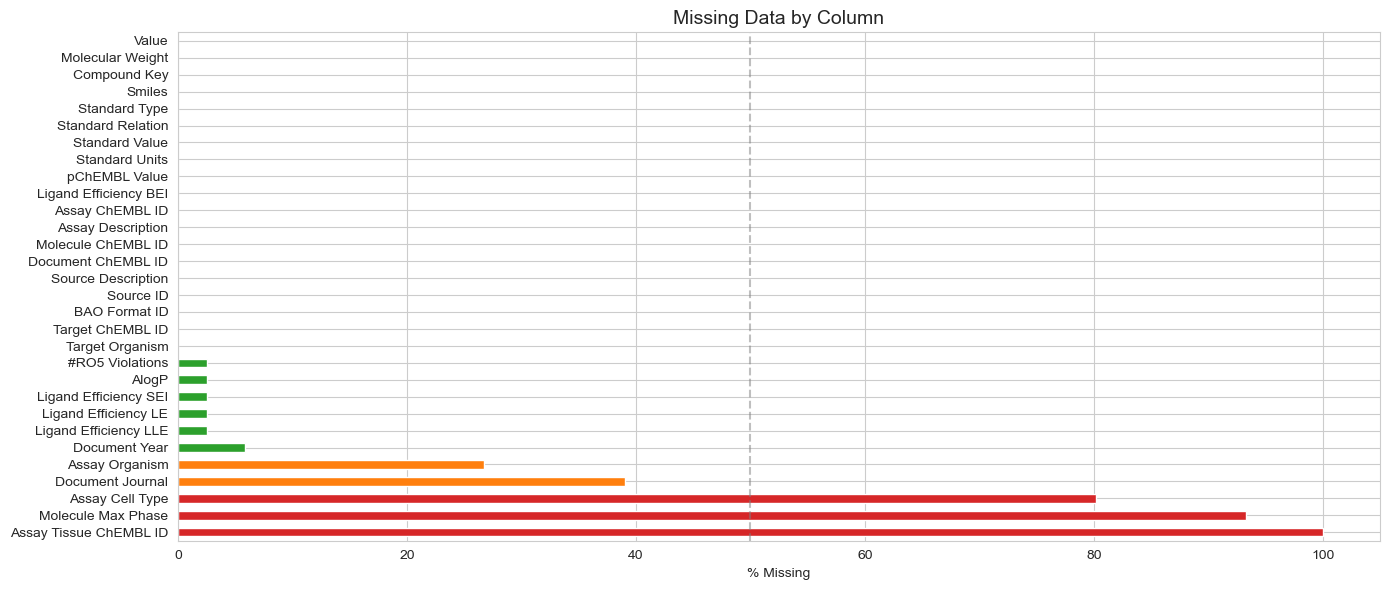


Columns with >50% missing data:
Assay Tissue ChEMBL ID    100.000000
Molecule Max Phase         93.278237
Assay Cell Type            80.179063


In [5]:
# Visualize missing data
fig, ax = plt.subplots(figsize=(14, 6))
missing_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
colors = ['#d62728' if v > 50 else '#ff7f0e' if v > 10 else '#2ca02c' for v in missing_pct.values]
missing_pct.plot(kind='barh', color=colors, ax=ax)
ax.set_xlabel('% Missing')
ax.set_title('Missing Data by Column', fontsize=14)
ax.axvline(x=50, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("\nColumns with >50% missing data:")
print(missing_pct[missing_pct > 50].to_string())

**Discussion:** Which missing columns are structurally expected vs. concerning?

- `Assay Tissue ChEMBL ID` is 100% missing — this target is a receptor, not tissue-specific, so this is expected.
- `Molecule Max Phase` is 93% missing — most compounds in ChEMBL are research compounds, not approved drugs.
- `Assay Cell Type` is 80% missing — only relevant for cell-based assays, not biochemical binding assays.
- These columns should not be dropped blindly; some carry useful information for the subset where they are present.

### 1.4 Basic Statistics

In [6]:
print(f"Total bioactivity records:     {len(df):,}")
print(f"Unique molecules:              {df['Molecule ChEMBL ID'].nunique():,}")
print(f"Unique assays:                 {df['Assay ChEMBL ID'].nunique():,}")
print(f"Unique documents:              {df['Document ChEMBL ID'].nunique():,}")
print(f"Years covered:                 {int(df['Document Year'].min())} – {int(df['Document Year'].max())}")

Total bioactivity records:     7,260
Unique molecules:              4,234
Unique assays:                 554
Unique documents:              350
Years covered:                 1999 – 2025


## 2. Understanding Bioactivity Semantics

### 2.1 The Core Concepts

ChEMBL standardizes bioactivity measurements into four key fields:

| Field | Meaning |
|-------|---------|
| `Standard Type` | The type of measurement: `IC50`, `EC50`, `Ki`, `Kd` |
| `Standard Relation` | The relationship to the value: `=` (exact), `>` (greater than), `<` (less than), `~` (approximate) |
| `Standard Value` | The numerical activity value |
| `Standard Units` | The unit of measurement (should be `nM` for binding data) |
| `pChEMBL Value` | The negative log-transformed activity: $\text{pChEMBL} = 9 - \log_{10}(\text{Value in nM})$ |

In [7]:
print("=== Standard Type distribution ===")
print(df['Standard Type'].value_counts())
print(f"\n=== Standard Relation distribution ===")
print(df['Standard Relation'].value_counts())
print(f"\n=== Standard Units distribution ===")
print(df['Standard Units'].value_counts())

=== Standard Type distribution ===
Standard Type
IC50    5693
EC50     831
Ki       684
Kd        52
Name: count, dtype: int64

=== Standard Relation distribution ===
Standard Relation
'='    7260
Name: count, dtype: int64

=== Standard Units distribution ===
Standard Units
nM    7260
Name: count, dtype: int64


**Good news:** All relations are `=` (exact measurements) and all units are `nM`. This means we don't need to handle censored data (`>`, `<`) or unit conversion. However, this is not guaranteed across all ChEMBL queries.

### 2.2 Validating pChEMBL Values

Let's verify that the `pChEMBL Value` column is correctly computed from `Standard Value`:

$$\text{pChEMBL} = 9 - \log_{10}(\text{Standard Value in nM})$$

In [8]:
# Compute expected pChEMBL and compare
df['pChEMBL_computed'] = 9 - np.log10(df['Standard Value'])

# Check for mismatches
mismatch = df[np.abs(df['pChEMBL Value'] - df['pChEMBL_computed']) > 0.1]
print(f"Records with pChEMBL mismatch (>0.1): {len(mismatch)}")

if len(mismatch) > 0:
    print("\nSample mismatches:")
    print(mismatch[['Molecule ChEMBL ID', 'Standard Type', 'Standard Value', 'pChEMBL Value', 'pChEMBL_computed']].head(10).to_string())
else:
    print("All pChEMBL values are consistent with the formula.")

Records with pChEMBL mismatch (>0.1): 0
All pChEMBL values are consistent with the formula.


### 2.3 Activity Value Distributions

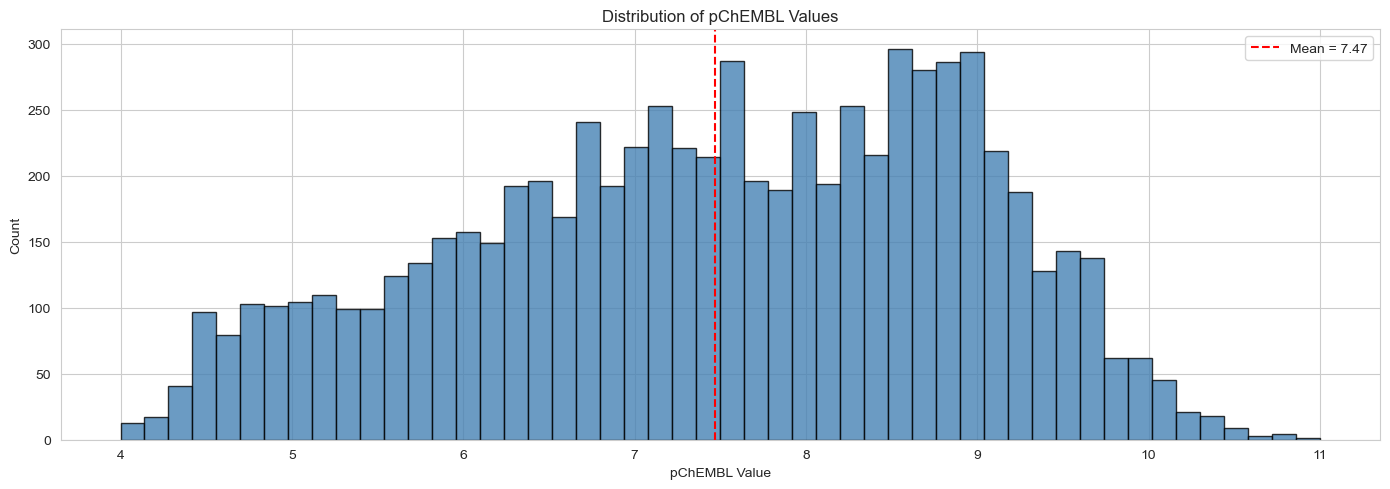


pChEMBL range: 4.00 – 11.00
Standard Value range: 0.0100 – 100000 nM


In [9]:
fig, axes = plt.subplots(1, 1, figsize=(14, 5))

# pChEMBL distribution
axes.hist(df['pChEMBL Value'], bins=50, edgecolor='black', color='steelblue', alpha=0.8)
axes.set_xlabel('pChEMBL Value')
axes.set_ylabel('Count')
axes.set_title('Distribution of pChEMBL Values')
axes.axvline(df['pChEMBL Value'].mean(), color='red', linestyle='--', label=f"Mean = {df['pChEMBL Value'].mean():.2f}")
axes.legend()

plt.tight_layout()
plt.show()

print(f"\npChEMBL range: {df['pChEMBL Value'].min():.2f} – {df['pChEMBL Value'].max():.2f}")
print(f"Standard Value range: {df['Standard Value'].min():.4f} – {df['Standard Value'].max():.0f} nM")

## 3. Endpoint Selection

### 3.1 The Problem of Mixed Endpoints

Our dataset contains four different measurement types:

| Endpoint | Count | Meaning |
|----------|-------|---------|
| IC50 | 5,693 | Concentration causing 50% inhibition |
| EC50 | 831 | Concentration causing 50% of maximal effect |
| Ki | 684 | Binding affinity |
| Kd | 52 | Dissociation constant |

Mixing them in a single model introduces label noise.

For this workshop, we'll explore the distributions first, then select a strategy.

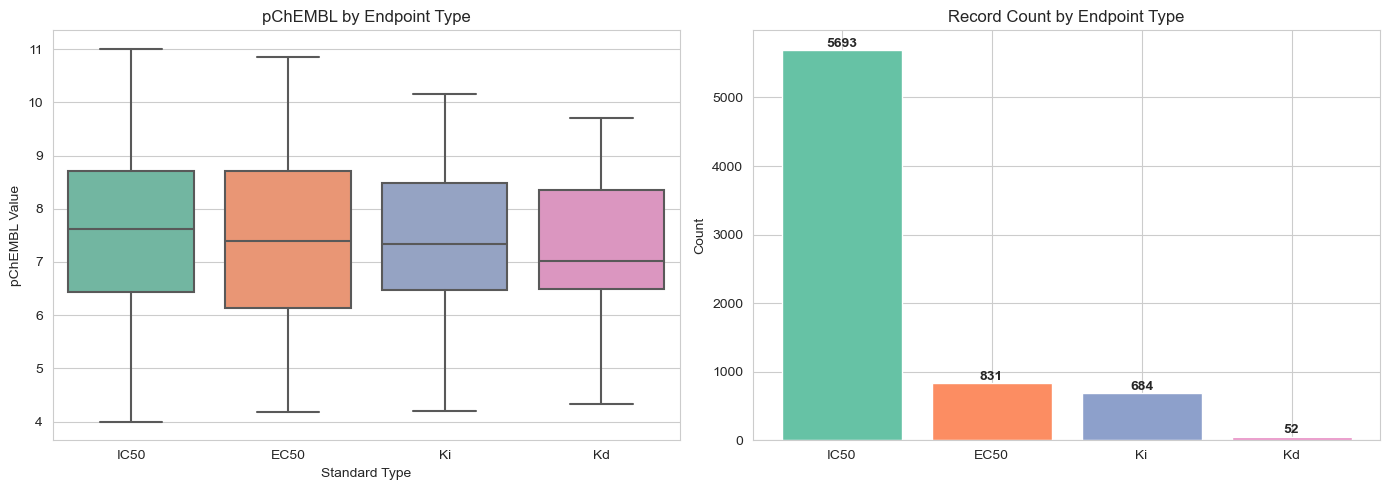

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot of pChEMBL by endpoint type
endpoint_order = ['IC50', 'EC50', 'Ki', 'Kd']
sns.boxplot(data=df, x='Standard Type', y='pChEMBL Value', order=endpoint_order, ax=axes[0], palette='Set2')
axes[0].set_title('pChEMBL by Endpoint Type')
axes[0].set_xlabel('Standard Type')

# Count plot
endpoint_counts = df['Standard Type'].value_counts()
set2_colors = sns.color_palette('Set2', len(endpoint_counts))
axes[1].bar(endpoint_counts.index, endpoint_counts.values, color=set2_colors)
axes[1].set_title('Record Count by Endpoint Type')
axes[1].set_ylabel('Count')
for i, v in enumerate(endpoint_counts.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [11]:
curation_options = pd.DataFrame({
    'Strategy': ['All endpoints', 'IC50 only', 'EC50 only', 'Ki only', 'Kd only'],
    'Records': [
        len(df),
        len(df[df['Standard Type'] == 'IC50']),
        len(df[df['Standard Type'] == 'EC50']),
        len(df[df['Standard Type'] == 'Ki']),
        len(df[df['Standard Type'] == 'Kd']),
    ],
})
curation_options['Unique Molecules'] = [
    df['Molecule ChEMBL ID'].nunique(),
    df[df['Standard Type'] == 'IC50']['Molecule ChEMBL ID'].nunique(),
    df[df['Standard Type'] == 'EC50']['Molecule ChEMBL ID'].nunique(),
    df[df['Standard Type'] == 'Ki']['Molecule ChEMBL ID'].nunique(),
    df[df['Standard Type'] == 'Kd']['Molecule ChEMBL ID'].nunique(),
]
curation_options

,Strategy,Records,Unique Molecules
0,All endpoints,7260,4234
1,IC50 only,5693,3290
2,EC50 only,831,710
3,Ki only,684,530
4,Kd only,52,38


### 3.2 Applying the Filter

For this workshop, we'll proceed with **IC50 only** since it is the largest subset and commonly used in QSAR benchmarks. We'll keep track of what we remove.

In [12]:
# Create a curation log to track filtering steps
curation_log = []
curation_log.append(('Starting dataset', len(df), df['Molecule ChEMBL ID'].nunique()))

# Filter to IC50 only
df_curated = df[df['Standard Type'] == 'IC50'].copy()
curation_log.append(('Filter: IC50 only', len(df_curated), df_curated['Molecule ChEMBL ID'].nunique()))

print(f"After IC50 filter: {len(df_curated):,} records, {df_curated['Molecule ChEMBL ID'].nunique():,} unique molecules")

After IC50 filter: 5,693 records, 3,290 unique molecules


## 4. Molecule-Level Curation

### 4.1 Checking SMILES Validity

SMILES strings are our molecular representation. We'll use RDKit to validate all structures.

In [13]:
# Check for missing SMILES
missing_smiles = df_curated['Smiles'].isna().sum()
print(f"Records with missing SMILES: {missing_smiles}")

# Validate SMILES with RDKit
valid_flags = []
canonical_smiles = []
for smi in df_curated['Smiles']:
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        valid_flags.append(True)
        canonical_smiles.append(Chem.MolToSmiles(mol))
    else:
        valid_flags.append(False)
        canonical_smiles.append(None)

df_curated['SMILES_Valid'] = valid_flags
df_curated['Canonical_SMILES'] = canonical_smiles

n_invalid = sum(1 for v in valid_flags if not v)
print(f"Records with invalid SMILES: {n_invalid}")
print(f"Records with valid SMILES: {sum(valid_flags):,}")

Records with missing SMILES: 0
Records with invalid SMILES: 0
Records with valid SMILES: 5,693


### 4.2 Standardize

Remove salts, neutralize, keep largest fragment

In [14]:
RDLogger.DisableLog('rdApp.*')

normalizer = rdMolStandardize.Normalizer()
remover = rdMolStandardize.LargestFragmentChooser()
charger = rdMolStandardize.Uncharger()

standardized_smiles = []
for smi in df_curated['Smiles']:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        standardized_smiles.append(None); continue
    try:
        mol = normalizer.normalize(mol)
        mol = remover.choose(mol)
        mol = charger.uncharge(mol)
        standardized_smiles.append(Chem.MolToSmiles(mol))
    except Exception:
        standardized_smiles.append(Chem.MolToSmiles(Chem.MolFromSmiles(smi)))

df_curated['Standardized_SMILES'] = standardized_smiles

before = len(df_curated)
df_curated = df_curated[df_curated['Standardized_SMILES'].notna()].copy()
curation_log.append(('Standardize SMILES', len(df_curated), df_curated['Molecule ChEMBL ID'].nunique()))

# Check for duplicates revealed by standardization
dup_smiles = df_curated['Standardized_SMILES'].duplicated().sum()
print(f"SMILES changed by standardization: {sum(1 for o, s in zip(df_curated['Canonical_SMILES'], df_curated['Standardized_SMILES']) if o != s)}")

SMILES changed by standardization: 74



Standardization may reveal that molecules with different SMILES (e.g., salt vs. free base) are actually the same compound. 



## 5. Duplicate Handling


### 5.1 Keep Highest pChEMBL per Molecule-Target-Document

When the same compound is measured multiple times in the **same publication** for the **same target**, keep only the highest activity value. This removes within-publication redundancy (e.g., dose-response replicates).

In [15]:
# Keep highest pChEMBL per (molecule, target, document)
before = len(df_curated)
df_curated = (
    df_curated
    .sort_values('pChEMBL Value', ascending=False)
    .drop_duplicates(subset=['Standardized_SMILES', 'Target ChEMBL ID', 'Document ChEMBL ID'])
)
curation_log.append(('Keep highest pChEMBL per molecule-target-document',
                      len(df_curated), df_curated['Standardized_SMILES'].nunique()))
print(f"Removed {before - len(df_curated)} within-publication duplicates")
print(f"Remaining: {len(df_curated):,} records")

Removed 1512 within-publication duplicates
Remaining: 4,181 records


### 5.2  Remove Exact Duplicates

Remove measurements where the same molecule-target pair has the **exact same** Standard Value across different publications. These are likely the same measurement reported in multiple papers.

In [16]:
#  Remove exact value duplicates
before = len(df_curated)
df_curated = df_curated.drop_duplicates(subset=['Standardized_SMILES', 'Target ChEMBL ID', 'Standard Value'])
curation_log.append(('Kramer Step 4a: Remove exact value duplicates',
                      len(df_curated), df_curated['Standardized_SMILES'].nunique()))
print(f"Removed {before - len(df_curated)} exact duplicates")

Removed 363 exact duplicates


### 5.3  Remove Rounding-Based Duplicates

If two publications report pChEMBL values within 0.02 of each other for the same molecule-target pair, they are likely the same measurement with different rounding. We round pChEMBL to 2 decimal places and remove duplicates.

In [17]:
# Remove rounding-based duplicates
before = len(df_curated)
df_curated = (
    df_curated
    .assign(pchembl_rounded=lambda x: x['pChEMBL Value'].round(2))
    .drop_duplicates(subset=['Standardized_SMILES', 'Target ChEMBL ID', 'pchembl_rounded'])
    .drop(columns=['pchembl_rounded'])
)
curation_log.append(('Remove rounding duplicates (0.02 pChEMBL)',
                      len(df_curated), df_curated['Standardized_SMILES'].nunique()))
print(f"Removed {before - len(df_curated)} rounding-based duplicates")
print(f"\nAfter pipeline: {len(df_curated):,} records, {df_curated['Standardized_SMILES'].nunique():,} molecules")

Removed 33 rounding-based duplicates

After pipeline: 3,785 records, 3,266 molecules




### 5.4 Duplicate Summary 

In [18]:
# Duplicate analysis 
print(f"Remaining records: {len(df_curated):,}")
print(f"Unique molecules: {df_curated['Standardized_SMILES'].nunique():,}")
print(f"Unique assays: {df_curated['Assay ChEMBL ID'].nunique():,}")
print(f"Duplicate molecule + assay combos: {df_curated.duplicated(subset=['Standardized_SMILES', 'Assay ChEMBL ID']).sum()}")
print(f"Duplicate standardized SMILES: {df_curated['Standardized_SMILES'].duplicated().sum()}")

mol_counts = df_curated.groupby('Standardized_SMILES').size()
print(f"\nMolecules with 1 measurement: {(mol_counts == 1).sum():,}")
print(f"Molecules with 2-5 measurements: {((mol_counts >= 2) & (mol_counts <= 5)).sum():,}")
print(f"Molecules with >5 measurements: {(mol_counts > 5).sum():,}")
print(f"Max measurements for one molecule: {mol_counts.max()}")

Remaining records: 3,785
Unique molecules: 3,266
Unique assays: 308
Duplicate molecule + assay combos: 0
Duplicate standardized SMILES: 519

Molecules with 1 measurement: 2,980
Molecules with 2-5 measurements: 277
Molecules with >5 measurements: 9
Max measurements for one molecule: 38


## 6. Chemical Space Visualization

To understand the diversity of our compound library, we visualize the chemical space using **t-SNE** (with PCA pre-reduction).

In [19]:
# Compute Morgan fingerprints on unique SMILES
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=512)
unique_smiles = df_curated['Standardized_SMILES'].unique()
smiles_to_fp = {}
for smi in unique_smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        smiles_to_fp[smi] = mfpgen.GetFingerprintAsNumPy(mol)

print(f"Unique SMILES: {len(unique_smiles):,}")
print(f"Valid fingerprints: {len(smiles_to_fp):,}")

Unique SMILES: 3,266
Valid fingerprints: 3,266


In [20]:
# PCA -> t-SNE on unique fingerprints
X_fp = np.array(list(smiles_to_fp.values()))
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_fp)
tsne = TSNE(n_components=2, init='pca', random_state=42, perplexity=30)
embedding = tsne.fit_transform(X_pca)

# Map back to unique SMILES
smiles_to_tsne = {smi: emb for smi, emb in zip(smiles_to_fp.keys(), embedding)}
df_curated['TSNE_1'] = df_curated['Standardized_SMILES'].map(lambda s: smiles_to_tsne.get(s, [None, None])[0])
df_curated['TSNE_2'] = df_curated['Standardized_SMILES'].map(lambda s: smiles_to_tsne.get(s, [None, None])[1])

print(f"t-SNE coordinates assigned to {df_curated['TSNE_1'].notna().sum():,} records")

t-SNE coordinates assigned to 3,785 records


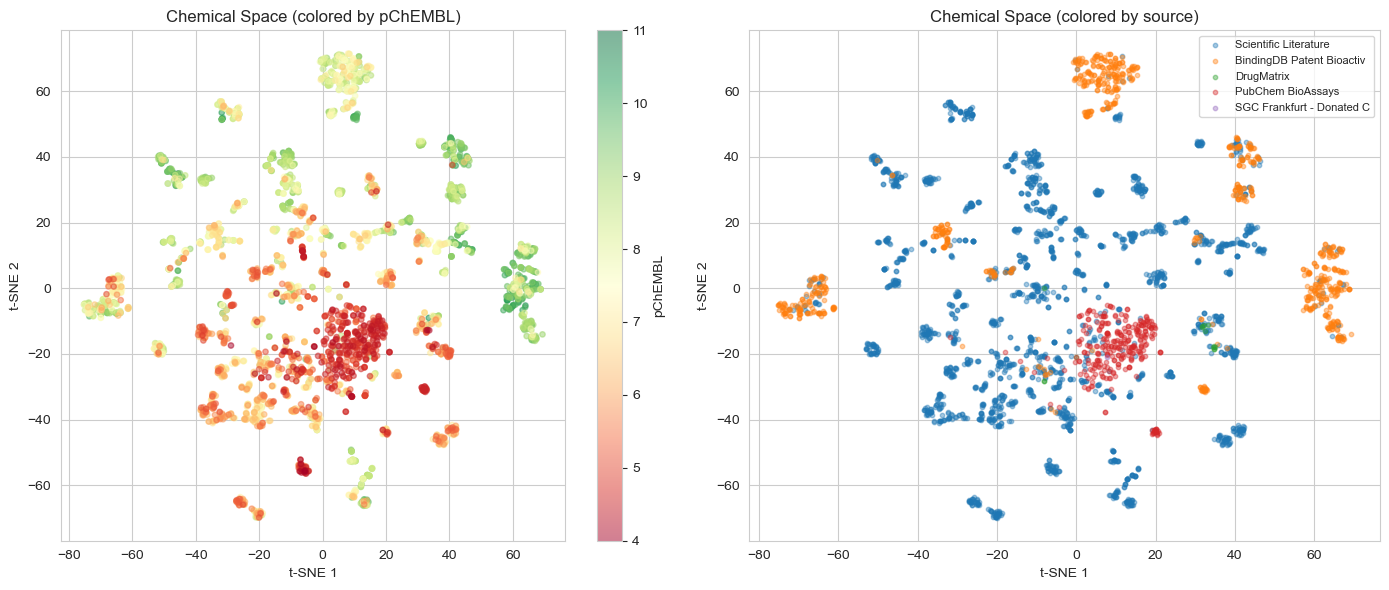

In [21]:
# Plot chemical space
df_unique = df_curated.drop_duplicates(subset='Standardized_SMILES').copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter = axes[0].scatter(df_unique['TSNE_1'], df_unique['TSNE_2'],
                          c=df_unique['pChEMBL Value'], cmap='RdYlGn', alpha=0.5, s=15)
axes[0].set_xlabel('t-SNE 1'); axes[0].set_ylabel('t-SNE 2')
axes[0].set_title('Chemical Space (colored by pChEMBL)')
plt.colorbar(scatter, ax=axes[0], label='pChEMBL')

sources_simplified = df_unique['Source Description'].str.split(',').str[0]
for src in sources_simplified.unique():
    mask = sources_simplified == src
    axes[1].scatter(df_unique.loc[mask, 'TSNE_1'], df_unique.loc[mask, 'TSNE_2'],
                    label=src[:25], alpha=0.4, s=10)
axes[1].set_xlabel('t-SNE 1'); axes[1].set_ylabel('t-SNE 2')
axes[1].set_title('Chemical Space (colored by source)')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 7. Value Consistency & Molecule Grids

How consistent are replicate measurements? We examine the pChEMBL spread for the most-measured compounds. High variability can signal label noise, but also genuine biological differences between assays.

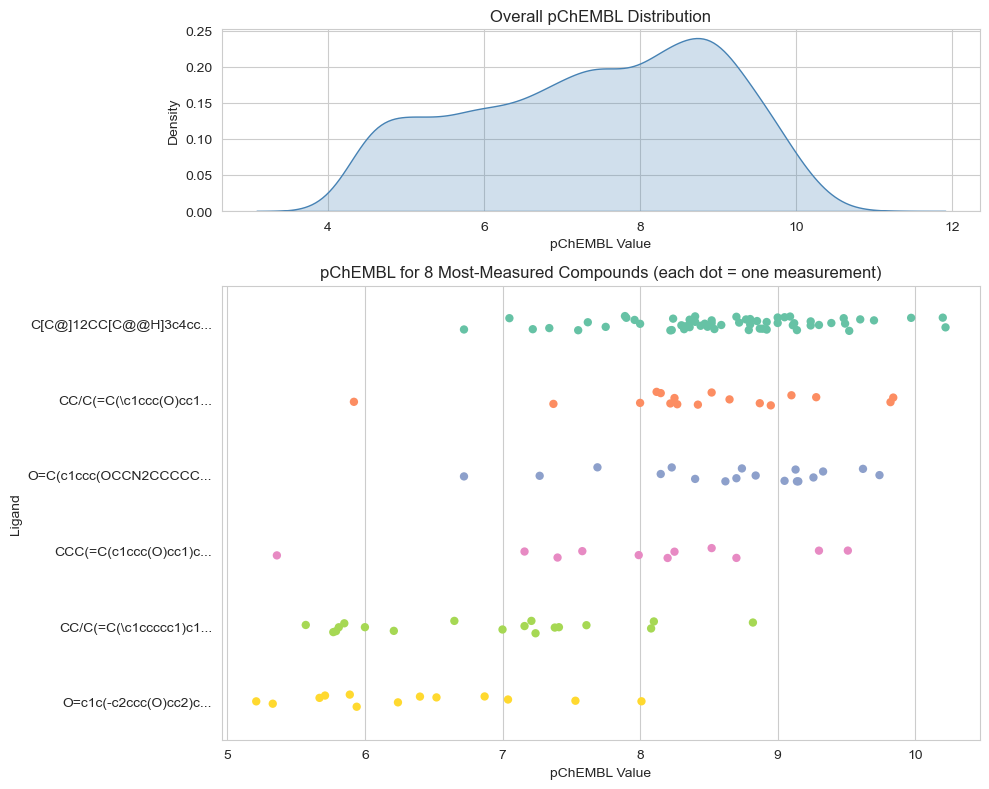


Median replicate std: 0.573 log units
Molecules with >1 measurement: 286


In [22]:
# Top 8 most-measured compounds
mol_measurement_counts = df_curated.groupby('Standardized_SMILES').size()
top8_smiles = mol_measurement_counts.nlargest(8).index.tolist()
top8_data = df_curated[df_curated['Standardized_SMILES'].isin(top8_smiles)].copy()
top8_data['SMILES_short'] = top8_data['Standardized_SMILES'].str[:20] + '...'

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [2, 5]})
sns.kdeplot(data=df_curated, x='pChEMBL Value', ax=ax1, fill=True, color='steelblue')
ax1.set_title('Overall pChEMBL Distribution')

sns.stripplot(data=top8_data, x='pChEMBL Value', y='SMILES_short', ax=ax2, size=6, palette='Set2')
ax2.set_title('pChEMBL for 8 Most-Measured Compounds (each dot = one measurement)')
ax2.set_ylabel('Ligand')
plt.tight_layout(); plt.show()

replicate_stds = df_curated.groupby('Standardized_SMILES')['pChEMBL Value'].std().dropna()
print(f"\nMedian replicate std: {replicate_stds.median():.3f} log units")
print(f"Molecules with >1 measurement: {(mol_measurement_counts > 1).sum()}")

### 7.1 Top Active Compounds

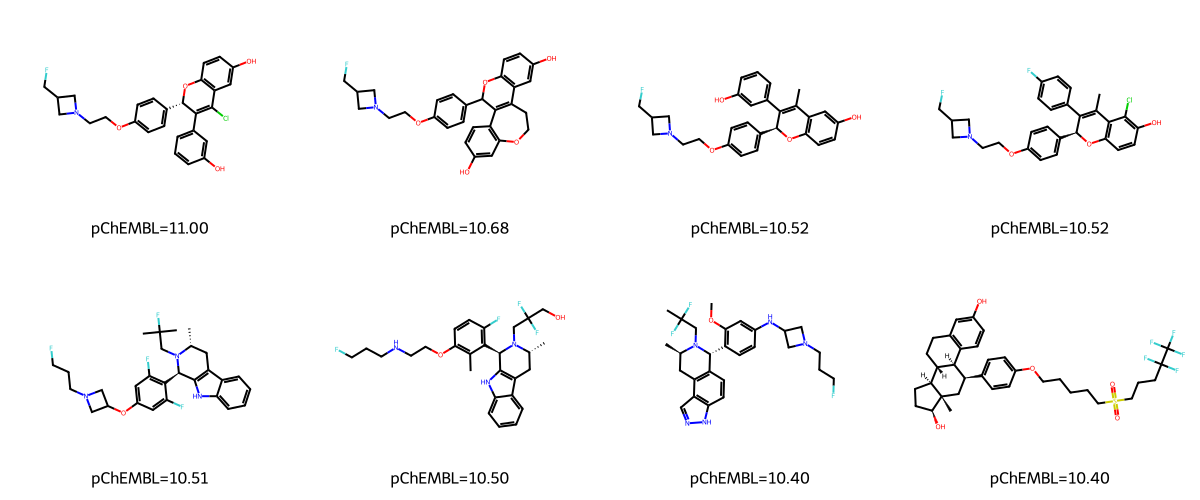

In [23]:
# Show the 8 most active compounds (highest single pChEMBL measurement)
top_active = df_curated.nlargest(9, 'pChEMBL Value').drop_duplicates(subset='Standardized_SMILES')
mols = [Chem.MolFromSmiles(smi) for smi in top_active['Standardized_SMILES']]
legends = [f"pChEMBL={p:.2f}" for p in top_active['pChEMBL Value']]
Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(300, 250), legends=legends)

## 8. Activity Classification

For classification models, we binarize activity. The threshold choice significantly affects class balance:

- **pChEMBL ≥ 5** (10 μM): permissive
- **pChEMBL ≥ 6** (1 μM): standard
- **pChEMBL ≥ 7** (100 nM): stringent

The same molecule can be active in one assay and inactive in another.

In [24]:
thresholds = [5, 6, 7, 8]
for t in thresholds:
    n_active = (df_curated['pChEMBL Value'] >= t).sum()
    n_inactive = (df_curated['pChEMBL Value'] < t).sum()
    print(f"pChEMBL >= {t}: Active={n_active}, Inactive={n_inactive}, Ratio=1:{n_active/max(1,n_inactive):.2f}")

pChEMBL >= 5: Active=3434, Inactive=351, Ratio=1:9.78
pChEMBL >= 6: Active=2904, Inactive=881, Ratio=1:3.30
pChEMBL >= 7: Active=2332, Inactive=1453, Ratio=1:1.60
pChEMBL >= 8: Active=1596, Inactive=2189, Ratio=1:0.73


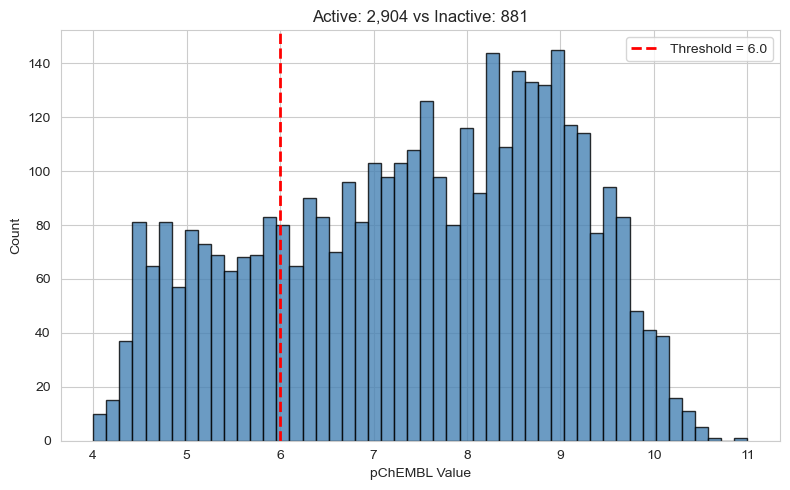

In [25]:
THRESHOLD = 6.0
df_curated['Active'] = (df_curated['pChEMBL Value'] >= THRESHOLD).astype(int)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df_curated['pChEMBL Value'], bins=50, edgecolor='black', color='steelblue', alpha=0.8)
ax.axvline(THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Threshold = {THRESHOLD}')
ax.set_xlabel('pChEMBL Value'); ax.set_ylabel('Count')
ax.set_title(f'Active: {df_curated["Active"].sum():,} vs Inactive: {(1-df_curated["Active"]).sum():,}')
ax.legend()
plt.tight_layout(); plt.show()

> **Discussion:** Some molecules have conflicting labels (active in one assay, inactive in another). How should we handle this during model training?

## 9. Data Splitting for ML

The choice of split affects how we evaluate model generalization. 

In [26]:
RANDOM_STATE = 42
N_SPLITS = 5

# Binary classification label (pChEMBL >= 6.0 is active)
ACTIVE_CUTOFF = 6.0
df_curated['y'] = (df_curated['pChEMBL Value'] >= ACTIVE_CUTOFF).astype(int)

work = df_curated.copy()
work['Mol'] = work['Standardized_SMILES'].map(Chem.MolFromSmiles)
work = work[work['Mol'].notna()].copy()

# Morgan fingerprints, same for all splits
fpgen = AllChem.GetMorganGenerator(radius=2, fpSize=2048) if hasattr(AllChem, 'GetMorganGenerator') else None
def fp_array(mol):
    fp = fpgen.GetFingerprint(mol) if fpgen else AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048)
    arr = np.zeros((2048,), dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr
X = np.vstack(work['Mol'].map(fp_array))

# Labels and molecule identifiers
Y = work['y'].to_numpy()
mol_ids = work['Standardized_SMILES'].to_numpy()
print('Fingerprint shape:', X.shape, '| labels:', Y.shape)

Fingerprint shape: (3785, 2048) | labels: (3785,)


### 9.1 Random K-Fold (by molecule)

A common splitting technique is k-fold split. In k-fold splits the data is splitted into k subsets, in such a way that each data point is part of the test set once.

The main advantages are that:

*   **Reduces overfitting**: by testing the model on multiple subsets, k-fold provides a better estimate of model performance.
*   **Works for Small Datasets**: since all data points are used for both training and validation, it's useful when you have limited data.

For example, if we choose to do a 5-fold split, the summary of the process would be:

**Fold 1**: Train on Folds 2, 3, 4, 5 | Test on Fold 1

**Fold 2**: Train on Folds 1, 3, 4, 5 | Test on Fold 2

**Fold 3**: Train on Folds 1, 2, 4, 5 | Test on Fold 3

**Fold 4**: Train on Folds 1, 2, 3, 5 | Test on Fold 4

**Fold 5**: Train on Folds 1, 2, 3, 4 | Test on Fold 5

In [27]:
folds = {}

# Group by molecule so the same molecule can never be in both train and test
groups = work['Standardized_SMILES'].to_numpy()

sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
folds['Random'] = list(sgkf.split(X, Y, groups))

# Show the size of each fold
for i, (tr, te) in enumerate(folds['Random'], 1):
    print(f"Fold {i}: train={len(tr)}, test={len(te)}, "
          f"test active fraction={Y[te].mean():.3f}, "
          f"overlap molecules={len(set(groups[tr]) & set(groups[te]))}")

Fold 1: train=3033, test=752, test active fraction=0.766, overlap molecules=0
Fold 2: train=3059, test=726, test active fraction=0.775, overlap molecules=0
Fold 3: train=3023, test=762, test active fraction=0.751, overlap molecules=0
Fold 4: train=3011, test=774, test active fraction=0.776, overlap molecules=0
Fold 5: train=3014, test=771, test active fraction=0.768, overlap molecules=0


### 9.2 Scaffold-Based Split

Now, insetad of just dividng the data randomly, we are gonig to divide it up based on the chemical scaffold of the ligands. This ensures that molecules with similar core structures (scaffolds) are kept together in either the training or test set, but not both. This is important in drug discovery because it ensures that the model is evaluated on ligands with new scaffolds it has not seen during training. 

In [28]:
# 1) Compute the scaffold for every molecule
work['Scaffold'] = work['Mol'].map(lambda m: MurckoScaffold.MurckoScaffoldSmiles(mol=m))

# 2) Group row indices by scaffold
scaffold_groups = {}
for idx, scaf in enumerate(work['Scaffold']):
    scaffold_groups.setdefault(scaf, []).append(idx)

# 3) Assign whole scaffolds to folds, keeping fold sizes balanced
scaffold_sizes = {s: len(v) for s, v in scaffold_groups.items()}
scaffold_sizes = dict(sorted(scaffold_sizes.items(), key=lambda kv: kv[1], reverse=True))

fold_scaffolds = [[] for _ in range(N_SPLITS)]
fold_sizes = np.zeros(N_SPLITS, dtype=int)
for scaf, n in scaffold_sizes.items():
    j = int(np.argmin(fold_sizes))          # put into the currently smallest fold
    fold_scaffolds[j].append(scaf)
    fold_sizes[j] += n

# 4) Build training and test sets
all_idx = np.arange(len(work))
folds['Scaffold'] = []
for j in range(N_SPLITS):
    test_idx = np.concatenate([np.array(scaffold_groups[s]) for s in fold_scaffolds[j]])
    train_idx = np.setdiff1d(all_idx, test_idx)
    folds['Scaffold'].append((train_idx.tolist(), test_idx.tolist()))

for i, (tr, te) in enumerate(folds['Scaffold'], 1):
    print(f"Fold {i}: Train={len(tr)} records, Test={len(te)} records")

Fold 1: Train=3028 records, Test=757 records
Fold 2: Train=3028 records, Test=757 records
Fold 3: Train=3028 records, Test=757 records
Fold 4: Train=3028 records, Test=757 records
Fold 5: Train=3028 records, Test=757 records


### 9.3 Butina clustering split

Butina clustering groups molecules by **fingerprint similarity** using a Tanimoto threshold. Each cluster is a neighborhood of similar compounds. 
We then assign whole clusters to folds so that a test molecule is structurally novel relative to training.


In [29]:
RDLogger.DisableLog('rdApp.*')

# 1) Morgan fingerprints as RDKit bit vectors
mols = [Chem.MolFromSmiles(s) for s in work['Standardized_SMILES']]
fps = [AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=2048) for m in mols]
n = len(fps)

# 2) Pairwise Tanimoto distance matrix (1 - similarity)
THRESHOLD = 0.65
D = np.zeros((n, n), dtype=np.float32)
for i in range(n):
    sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps)
    D[i] = 1 - np.array(sims, dtype=np.float32)

# 3) Clustering
#    Iterate from the molecule with the most neighbours; each unassigned
#    molecule starts a new cluster and claims all neighbours within cutoff.
assigned = np.full(n, -1, dtype=int)
clusters = {}
for i in np.argsort(np.sum(D, axis=1)):
    if assigned[i] != -1:
        continue
    cid = len(clusters)
    clusters[cid] = []
    members = np.flatnonzero(D[i] <= (1 - THRESHOLD))
    for m in members:
        if assigned[m] == -1:
            assigned[m] = cid
            clusters[cid].append(m)

# 4) Assign whole clusters to folds, balancing sizes
rng = np.random.default_rng(RANDOM_STATE)
cluster_sizes = {c: len(v) for c, v in clusters.items()}
cluster_sizes = dict(sorted(cluster_sizes.items(), key=lambda kv: kv[1], reverse=True))
fold_clusters = [[] for _ in range(N_SPLITS)]
fold_sizes = np.zeros(N_SPLITS, dtype=int)
for c, size in cluster_sizes.items():
    j = int(np.argmin(fold_sizes))
    fold_clusters[j].append(c)
    fold_sizes[j] += size

# 5) Build training and test sets
all_idx = np.arange(n)
folds['Butina'] = []
for j in range(N_SPLITS):
    test_idx = np.concatenate([np.array(clusters[c]) for c in fold_clusters[j]])
    train_idx = np.setdiff1d(all_idx, test_idx)
    folds['Butina'].append((train_idx.tolist(), test_idx.tolist()))

print('Number of Butina clusters:', len(clusters))
for i, (tr, te) in enumerate(folds['Butina'], 1):
    print(f"Fold {i}: Train={len(tr)} records, Test={len(te)} records")

Number of Butina clusters: 1094
Fold 1: Train=3028 records, Test=757 records
Fold 2: Train=3028 records, Test=757 records
Fold 3: Train=3028 records, Test=757 records
Fold 4: Train=3028 records, Test=757 records
Fold 5: Train=3028 records, Test=757 records


### 9.4 Assay-based split

An assay-based split holds out **entire assays** (by `Assay ChEMBL ID`), so every test compound comes from an assay never seen during training. This follows the assay-aware evaluation paradigm from the [ChemRxiv paper](https://doi.org/10.26434/chemrxiv-2025-zsk6d/v2), which argues that ML should be evaluated on generalization to new assays, not just new molecules.

The mechanics are identical to the scaffold split, but the grouping key is the assay instead of the scaffold.

In [30]:
# 1) Group row indices by assay
assay_groups = {}
for idx, assay in enumerate(work['Assay ChEMBL ID'].fillna('unknown')):
    assay_groups.setdefault(assay, []).append(idx)

# 2) Assign whole assays to folds, balancing sizes
assay_sizes = {a: len(v) for a, v in assay_groups.items()}
assay_sizes = dict(sorted(assay_sizes.items(), key=lambda kv: kv[1], reverse=True))
fold_assays = [[] for _ in range(N_SPLITS)]
fold_sizes = np.zeros(N_SPLITS, dtype=int)
for a, size in assay_sizes.items():
    j = int(np.argmin(fold_sizes))
    fold_assays[j].append(a)
    fold_sizes[j] += size

# 3) Build training and test sets
all_idx = np.arange(len(work))
folds['Assay'] = []
for j in range(N_SPLITS):
    test_idx = np.concatenate([np.array(assay_groups[a]) for a in fold_assays[j]])
    train_idx = np.setdiff1d(all_idx, test_idx)
    folds['Assay'].append((train_idx.tolist(), test_idx.tolist()))

print('Number of assays:', len(assay_groups))
for i, (tr, te) in enumerate(folds['Assay'], 1):
    print(f"Fold {i}: Train={len(tr)} records, Test={len(te)} records")

Number of assays: 308
Fold 1: Train=3028 records, Test=757 records
Fold 2: Train=3028 records, Test=757 records
Fold 3: Train=3028 records, Test=757 records
Fold 4: Train=3028 records, Test=757 records
Fold 5: Train=3028 records, Test=757 records


### 9.5 Compare performance and dataset composition


In [31]:
model = make_pipeline(
    StandardScaler(with_mean=False),
    RandomForestClassifier(
        n_estimators=500,          
        max_depth=None,           
        min_samples_split=2,
        min_samples_leaf=1,
        class_weight='balanced',   
        random_state=RANDOM_STATE,
        n_jobs=-1                  
    )
)

records = []
for method, fold_list in folds.items():
    for fold, (train_idx, test_idx) in enumerate(fold_list, 1):
        train_idx = np.asarray(train_idx)
        test_idx = np.asarray(test_idx)
        
        if len(np.unique(Y[train_idx])) < 2 or len(np.unique(Y[test_idx])) < 2:
            continue
        
        fitted = clone(model).fit(X[train_idx], Y[train_idx])
        prob = fitted.predict_proba(X[test_idx])[:, 1]
        pred = (prob >= 0.5).astype(int)
        y = Y[test_idx]
        
        records.append({
            'split': method,
            'fold': fold,
            'ROC-AUC': roc_auc_score(y, prob),
            'PR-AUC': average_precision_score(y, prob),
            'Balanced accuracy': balanced_accuracy_score(y, pred),
            'MCC': matthews_corrcoef(y, pred),
            'n_test': len(test_idx),
            'active_test': y.mean()
        })

results = pd.DataFrame(records)
results.head()

,split,fold,ROC-AUC,PR-AUC,Balanced accuracy,MCC,n_test,active_test
0,Random,1,0.943276,0.977320,0.828598,0.701660,752,0.765957
1,Random,2,0.948899,0.980858,0.845008,0.718317,726,0.775482
2,Random,3,0.941558,0.976589,0.855364,0.725300,762,0.750656
3,Random,4,0.954724,0.982793,0.861099,0.741264,774,0.776486
4,Random,5,0.932329,0.977182,0.817393,0.670366,771,0.767834


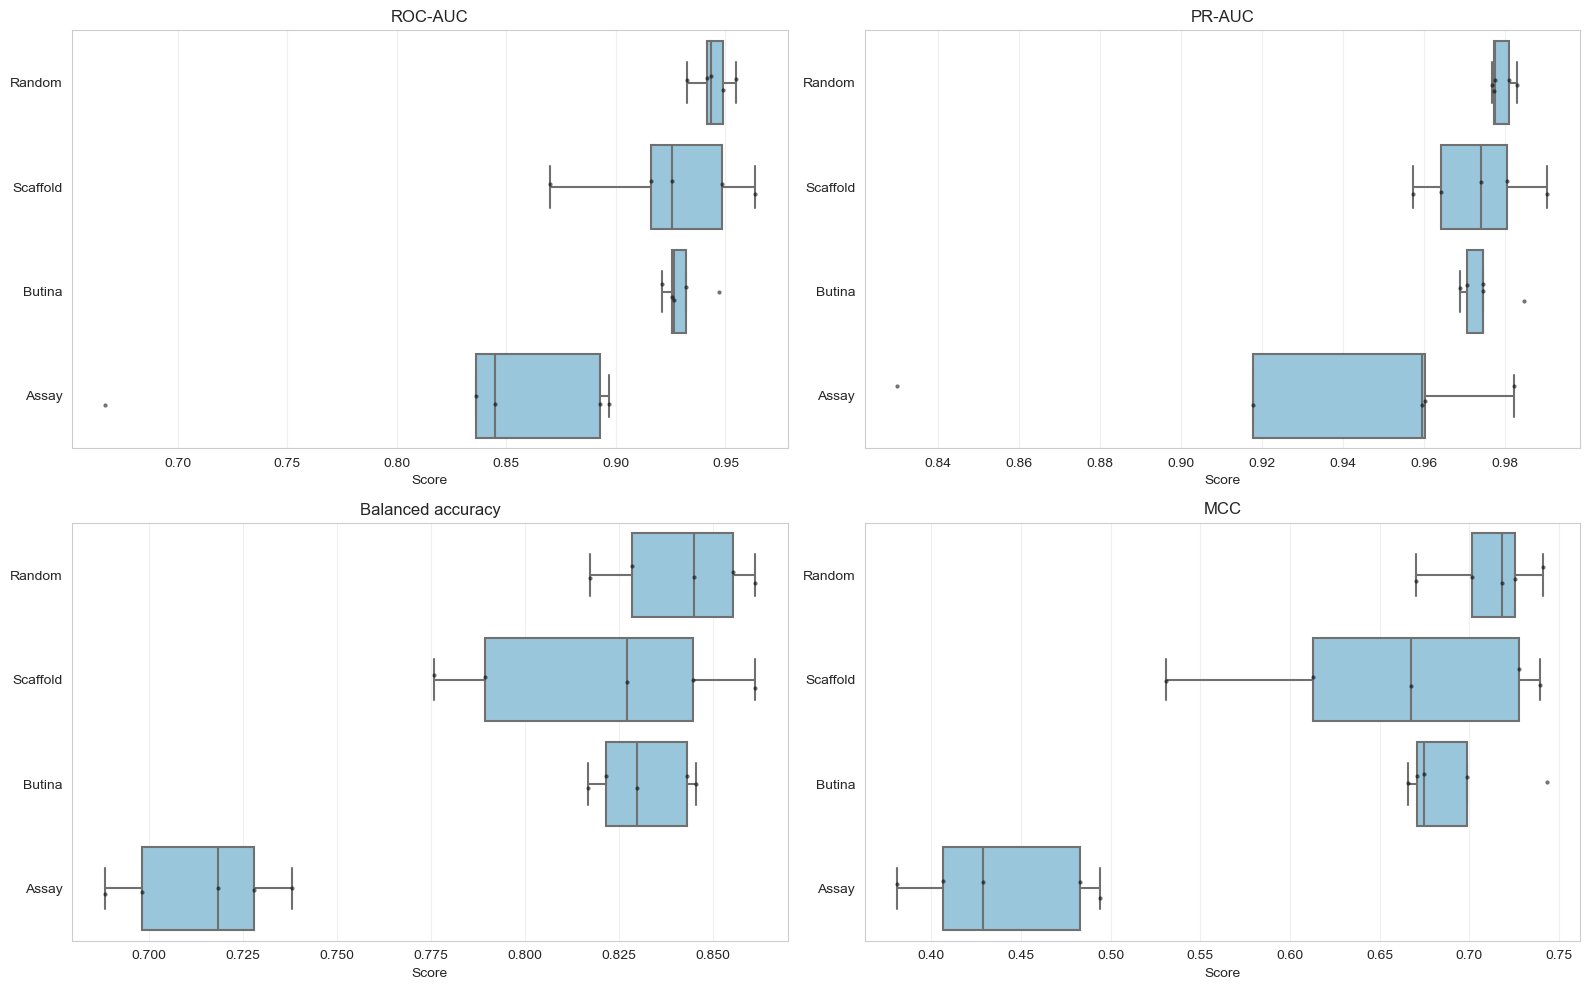

ROC-AUC        PR-AUC        Balanced accuracy           MCC       
            mean    std   mean    std              mean    std   mean    std
split                                                                       
Assay      0.827  0.094  0.930  0.061             0.714  0.021  0.439  0.049
Butina     0.930  0.010  0.975  0.006             0.831  0.013  0.691  0.032
Random     0.944  0.008  0.979  0.003             0.841  0.018  0.711  0.027
Scaffold   0.925  0.036  0.973  0.013             0.820  0.036  0.656  0.086

In [32]:
metric_order = ['ROC-AUC', 'PR-AUC', 'Balanced accuracy', 'MCC']
long = results.melt(id_vars=['split', 'fold'], value_vars=metric_order, var_name='Metric', value_name='Score')

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False)
for ax, metric in zip(axes.flat, metric_order):
    sns.boxplot(data=long[long['Metric'] == metric], x='Score', y='split',
                order=['Random', 'Scaffold', 'Butina', 'Assay'], ax=ax, color='#8ecae6', showfliers=False)
    sns.stripplot(data=long[long['Metric'] == metric], x='Score', y='split',
                  order=['Random', 'Scaffold', 'Butina', 'Assay'], ax=ax, color='black', size=3, alpha=.55)
    ax.set_title(metric); ax.set_ylabel(''); ax.grid(axis='x', alpha=.3)
plt.tight_layout()
plt.show()


summary = results.groupby('split')[metric_order].agg(['mean', 'std']).round(3)
summary

### 9.8 Interpretation

1. Why is data cujration such an important process?
2. Does random splitting produce optimistic performance because close analogues occur in both train and test?
3. How does splitting method choice influence generalizability? How can we be sure?





### References

- [Dr. Michael Backenköhler, Mr. Joschka Groß, Prof. Andrea Volkamer. ChemRxiv (2026)](https://doi.org/10.26434/chemrxiv-2025-zsk6d/v2)
- [Kramer et al. (2012) — J. Med. Chem. 55, 5165-5173](https://doi.org/10.1021/jm300131x)
- [ChEMBL Documentation](https://chembl.gitbook.io/chembl-interface-documentation)
- [RDKit Documentation](https://www.rdkit.org/docs/)